In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model
import tensorflow.keras.backend as K

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


2026-06-16 08:06:02.191264: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781597162.613929      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781597162.730947      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781597163.725703      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781597163.725745      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781597163.725748      58 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
!pip install mediapipe -q

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

# Download model MediaPipe
model_url = 'https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite'
model_path = '/kaggle/working/face_detector.tflite'
if not os.path.exists(model_path):
    urllib.request.urlretrieve(model_url, model_path)
    print("Downloaded face detector model")

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.FaceDetectorOptions(
    base_options=base_options,
    min_detection_confidence=0.5
)
detector = vision.FaceDetector.create_from_options(options)
print("MediaPipe Face Detector OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 93.5 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.6 which is incompatible.
Downloaded face detector model
MediaPipe Face Detector OK


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781597199.622278     143 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [4]:
BASE = '/kaggle/input/datasets/reubensuju/celeb-df-v2'

for folder in sorted(os.listdir(BASE)):
    full = os.path.join(BASE, folder)
    if os.path.isdir(full):
        files = os.listdir(full)
        mp4s = [f for f in files if f.endswith('.mp4')]
        print(f"{folder:25s} → {len(mp4s)} videos")
    else:
        print(f"{folder:25s} → (file)")

Celeb-real                → 590 videos
Celeb-synthesis           → 5639 videos
List_of_testing_videos.txt → (file)
YouTube-real              → 300 videos


In [5]:
test_list_path = f'{BASE}/List_of_testing_videos.txt'

test_videos = []
with open(test_list_path, 'r') as f:
    for line in f:
        label, path = line.strip().split(' ')
        folder, filename = path.split('/')
        test_videos.append({
            'label': int(label),   # 1=real, 0=fake
            'folder': folder,
            'filename': filename
        })

df_test = pd.DataFrame(test_videos)
print(f"Tổng test videos: {len(df_test)}")
print(df_test['label'].value_counts().rename({1: 'real', 0: 'fake'}))
print()
print(df_test['folder'].value_counts())
print()
print(df_test.head())

Tổng test videos: 518
label
fake    340
real    178
Name: count, dtype: int64

folder
Celeb-synthesis    340
Celeb-real         108
YouTube-real        70
Name: count, dtype: int64

   label        folder   filename
0      1  YouTube-real  00170.mp4
1      1  YouTube-real  00208.mp4
2      1  YouTube-real  00063.mp4
3      1  YouTube-real  00024.mp4
4      1  YouTube-real  00021.mp4


In [6]:
# Tập hợp các video thuộc test set (để loại ra)
test_set = set(
    df_test['folder'] + '/' + df_test['filename']
)

# Gom tất cả video, gán nhãn
all_videos = []

for fname in os.listdir(f'{BASE}/Celeb-real'):
    if fname.endswith('.mp4'):
        key = f'Celeb-real/{fname}'
        all_videos.append({
            'folder': 'Celeb-real',
            'filename': fname,
            'label': 1,       # real
            'in_test': key in test_set
        })

for fname in os.listdir(f'{BASE}/YouTube-real'):
    if fname.endswith('.mp4'):
        key = f'YouTube-real/{fname}'
        all_videos.append({
            'folder': 'YouTube-real',
            'filename': fname,
            'label': 1,       # real
            'in_test': key in test_set
        })

for fname in os.listdir(f'{BASE}/Celeb-synthesis'):
    if fname.endswith('.mp4'):
        key = f'Celeb-synthesis/{fname}'
        all_videos.append({
            'folder': 'Celeb-synthesis',
            'filename': fname,
            'label': 0,       # fake
            'in_test': key in test_set
        })

df_all = pd.DataFrame(all_videos)

# Tách train pool (không thuộc test)
df_trainpool = df_all[df_all['in_test'] == False].copy()

print(f"Tổng videos: {len(df_all)}")
print(f"Test  videos: {len(df_all[df_all['in_test']==True])}")
print(f"Train pool  : {len(df_trainpool)}")
print()
print("Train pool label distribution:")
print(df_trainpool['label'].value_counts().rename({1:'real', 0:'fake'}))

Tổng videos: 6529
Test  videos: 518
Train pool  : 6011

Train pool label distribution:
label
fake    5299
real     712
Name: count, dtype: int64


Train: 4808 videos
  real: 570
  fake: 4238

Val  : 1203 videos
  real: 142
  fake: 1061

Test : 518 videos
  real: 178
  fake: 340


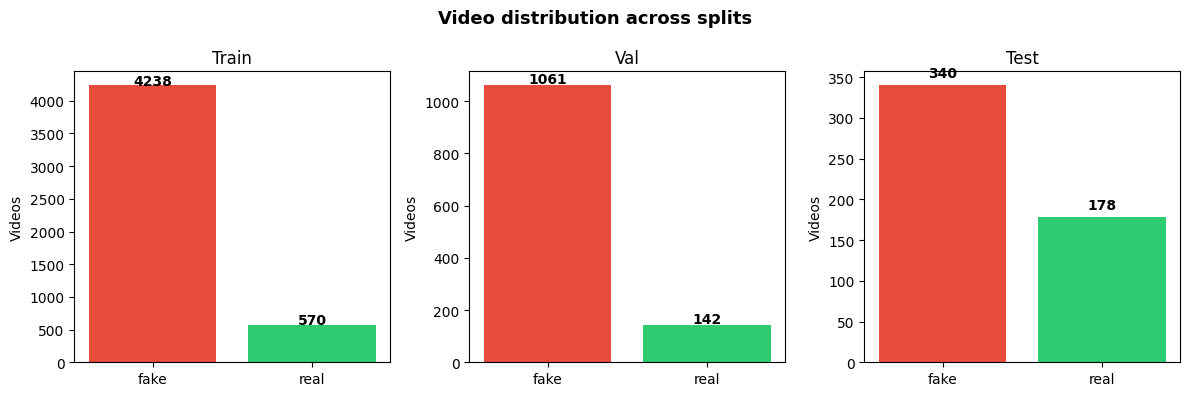

In [7]:
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(
    df_trainpool,
    test_size=0.2,
    random_state=42,
    stratify=df_trainpool['label']   # giữ tỉ lệ real/fake đều nhau
)

print(f"Train: {len(df_train)} videos")
print(f"  real: {(df_train['label']==1).sum()}")
print(f"  fake: {(df_train['label']==0).sum()}")
print()
print(f"Val  : {len(df_val)} videos")
print(f"  real: {(df_val['label']==1).sum()}")
print(f"  fake: {(df_val['label']==0).sum()}")
print()
print(f"Test : {len(df_test)} videos")
print(f"  real: {(df_test['label']==1).sum()}")
print(f"  fake: {(df_test['label']==0).sum()}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, counts) in zip(axes, [
    ('Train', df_train['label'].value_counts()),
    ('Val',   df_val['label'].value_counts()),
    ('Test',  df_test['label'].value_counts()),
]):
    ax.bar(['fake','real'], [counts.get(0,0), counts.get(1,0)],
           color=['#e74c3c','#2ecc71'])
    ax.set_title(name)
    ax.set_ylabel('Videos')
    for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Video distribution across splits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
import shutil

WORK_DIR          = '/kaggle/working/frames'
FRAMES_REAL_TRAIN = 22
FRAMES_FAKE_TRAIN = 3
FRAMES_REAL_VAL   = 16
FRAMES_FAKE_VAL   = 2
FRAMES_TEST       = 6

def extract_face_frames(video_path, out_dir, max_frames=10, margin=0.3):
    os.makedirs(out_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return 0

    indices = np.linspace(0, total - 1, min(max_frames * 4, total), dtype=int)
    saved = 0

    for idx in indices:
        if saved >= max_frames:
            break
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            continue

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

        result = detector.detect(mp_image)

        if result.detections:
            # Lấy detection confidence cao nhất
            best = max(result.detections, key=lambda d: d.categories[0].score)
            bb   = best.bounding_box
            x, y, w, h = bb.origin_x, bb.origin_y, bb.width, bb.height

            mx = int(w * margin)
            my = int(h * margin)
            x1 = max(0, x - mx)
            y1 = max(0, y - my)
            x2 = min(rgb.shape[1], x + w + mx)
            y2 = min(rgb.shape[0], y + h + my)

            face_crop = frame[y1:y2, x1:x2]
            if face_crop.size == 0:
                face_crop = frame
            face_crop = cv2.resize(face_crop, (224, 224))
        else:
            # Fallback: resize toàn frame
            face_crop = cv2.resize(frame, (224, 224))

        cv2.imwrite(os.path.join(out_dir, f'{saved:04d}.jpg'), face_crop)
        saved += 1

    cap.release()
    return saved

def extract_split_balanced(df, split_name, frames_real, frames_fake):
    label_map  = {1: 'real', 0: 'fake'}
    frames_map = {1: frames_real, 0: frames_fake}
    total      = len(df)
    failed     = []

    for pos, idx in enumerate(list(df.index)):
        row        = df.loc[idx]
        video_path = f"{BASE}/{row['folder']}/{row['filename']}"
        label_str  = label_map[row['label']]
        max_frames = frames_map[row['label']]
        video_stem = Path(row['filename']).stem
        out_dir    = f"{WORK_DIR}/{split_name}/{label_str}/{row['folder']}_{video_stem}"

        n = extract_face_frames(video_path, out_dir, max_frames=max_frames)
        if n == 0:
            failed.append(video_path)

        done = pos + 1
        if done % 200 == 0 or done == total:
            print(f"  [{split_name}] {done}/{total} | failed={len(failed)}")

    return failed

# Xóa frames cũ
if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)
    print("Đã xóa frames cũ")

print("\n=== Extract face frames (MediaPipe) ===")
print(">>> Train...")
failed_train = extract_split_balanced(df_train, 'train',
                                      FRAMES_REAL_TRAIN, FRAMES_FAKE_TRAIN)
print(">>> Val...")
failed_val   = extract_split_balanced(df_val, 'val',
                                      FRAMES_REAL_VAL, FRAMES_FAKE_VAL)
print(">>> Test...")
failed_test  = extract_split_balanced(df_test, 'test',
                                      frames_real=FRAMES_TEST,
                                      frames_fake=FRAMES_TEST)

# Đếm kết quả
print("\n=== Kết quả ===")
total_frames = 0
counts = {}
for split in ['train', 'val', 'test']:
    counts[split] = {}
    for label in ['real', 'fake']:
        path = Path(f'{WORK_DIR}/{split}/{label}')
        if path.exists():
            n = sum(len(list(p.glob('*.jpg'))) for p in path.iterdir())
        else:
            n = 0
        counts[split][label] = n
        total_frames += n

for split, lbls in counts.items():
    total_split = sum(lbls.values())
    print(f"  {split:5s}: real={lbls['real']:6d}, fake={lbls['fake']:6d} "
          f"| total={total_split:6d} ({total_split/total_frames*100:.2f}%)")

print(f"\nTổng frames: {total_frames}")
print(f"Failed: train={len(failed_train)}, val={len(failed_val)}, test={len(failed_test)}")


=== Extract face frames (MediaPipe) ===
>>> Train...
  [train] 200/4808 | failed=0
  [train] 400/4808 | failed=0
  [train] 600/4808 | failed=0
  [train] 800/4808 | failed=0
  [train] 1000/4808 | failed=0
  [train] 1200/4808 | failed=0
  [train] 1400/4808 | failed=0
  [train] 1600/4808 | failed=0
  [train] 1800/4808 | failed=0
  [train] 2000/4808 | failed=0
  [train] 2200/4808 | failed=0
  [train] 2400/4808 | failed=0
  [train] 2600/4808 | failed=0
  [train] 2800/4808 | failed=0
  [train] 3000/4808 | failed=0
  [train] 3200/4808 | failed=0
  [train] 3400/4808 | failed=0
  [train] 3600/4808 | failed=0
  [train] 3800/4808 | failed=0
  [train] 4000/4808 | failed=0
  [train] 4200/4808 | failed=0
  [train] 4400/4808 | failed=0
  [train] 4600/4808 | failed=0
  [train] 4800/4808 | failed=0
  [train] 4808/4808 | failed=0
>>> Val...
  [val] 200/1203 | failed=0
  [val] 400/1203 | failed=0
  [val] 600/1203 | failed=0
  [val] 800/1203 | failed=0
  [val] 1000/1203 | failed=0
  [val] 1200/1203 | fai

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 64
WORK_DIR = '/kaggle/working/frames'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f'{WORK_DIR}/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = val_datagen.flow_from_directory(
    f'{WORK_DIR}/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = val_datagen.flow_from_directory(
    f'{WORK_DIR}/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)
print(f"Train: {train_gen.samples} frames")
print(f"Val  : {val_gen.samples} frames")
print(f"Test : {test_gen.samples} frames")

Found 25233 images belonging to 2 classes.
Found 4394 images belonging to 2 classes.
Found 3108 images belonging to 2 classes.
Class indices: {'fake': 0, 'real': 1}
Train: 25233 frames
Val  : 4394 frames
Test : 3108 frames


In [10]:
def build_cnn_block(x, filters, dropout_rate=0.3):
    x = layers.Conv2D(
        filters,
        kernel_size=(3, 3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

def build_mhsa_block(x):
    seq_len = x.shape[1] * x.shape[2]   # 14×14 = 196
    x_reshaped = layers.Reshape((seq_len, 256))(x)
    x_drop = layers.Dropout(0.3)(x_reshaped)
    attn_output = layers.MultiHeadAttention(
        num_heads=4,
        key_dim=64,
        dropout=0.3
    )(x_drop, x_drop)
    x_residual = layers.Add()([x_reshaped, attn_output])
    x_norm = layers.LayerNormalization()(x_residual)
    return x_norm

# --- Build ---
inputs = layers.Input(shape=(224, 224, 3))

x = build_cnn_block(inputs, filters=32)    # 224→112
x = build_cnn_block(x,      filters=64)    # 112→56
x = build_cnn_block(x,      filters=128)   # 56→28
x = build_cnn_block(x,      filters=256)   # 28→14

x = build_mhsa_block(x)

x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(128)(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64)(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

I0000 00:00:1781597975.171582      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781597975.177661      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 112, 112,  │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 56, 56,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     73,856 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 28, 28,    │          0 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │    295,168 │ dropout_2[0][0] 

 Total params: 696,001 (2.66 MB)

 Trainable params: 694,657 (2.65 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [11]:
def focal_loss(alpha=0.75, gamma=2.0):
    def loss_fn(y_true, y_pred):
        y_pred = K.clip(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = K.pow(1 - p_t, gamma)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return K.mean(alpha_t * focal_weight * bce)
    return loss_fn

# Tính class weight để hỗ trợ thêm 
total = train_gen.samples
n_real = (train_gen.classes == 1).sum()
n_fake = (train_gen.classes == 0).sum()
weight_real = total / (2 * n_real)
weight_fake = total / (2 * n_fake)
class_weight = {0: weight_fake, 1: weight_real}

print(f"n_real={n_real}, n_fake={n_fake}")
print(f"class_weight: fake={weight_fake:.3f}, real={weight_real:.3f}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=focal_loss(alpha=0.25, gamma=2.0),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("\nModel compiled OK")

n_real=12519, n_fake=12714
class_weight: fake=0.992, real=1.008

Model compiled OK


In [ ]:
import os
os.remove('/kaggle/working/best_model.keras')
os.remove('/kaggle/working/backup_epoch.keras')

In [ ]:
CHECKPOINT_PATH = '/kaggle/working/best_model.keras'
BACKUP_PATH     = '/kaggle/working/backup_epoch.keras'

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=7,
        restore_best_weights=True,
        mode='max', verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5,
        patience=3, min_lr=1e-6,
        mode='max', verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH, monitor='val_auc',
        save_best_only=True, mode='max', verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        BACKUP_PATH, save_best_only=False, verbose=0
    )
]

history = model.fit(
    train_gen,
    epochs=3,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print(f"\nBest val_auc:      {max(history.history['val_auc']):.4f}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

In [ ]:
# ============================================
START_EPOCH = 3    # thay số này mỗi lần
END_EPOCH   = 6   # thay số này mỗi lần
# ============================================

CHECKPOINT_PATH = '/kaggle/working/best_model.keras'
BACKUP_PATH     = '/kaggle/working/backup_epoch.keras'


model = tf.keras.models.load_model(
    'kaggle/working/best_model.keras',
    custom_objects={'loss_fn': focal_loss(alpha=0.25, gamma=2.0)}
)
print(f"Loaded best model OK")

# LR giảm dần theo số lần resume
lr = 1e-4 * (0.8 ** (START_EPOCH // 10))
print(f"Resume epoch {START_EPOCH}→{END_EPOCH}, lr={lr:.6f}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss=focal_loss(alpha=0.5, gamma=2.0),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=7,
        restore_best_weights=True,
        mode='max', verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5,
        patience=3, min_lr=1e-6,
        mode='max', verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH, monitor='val_auc',
        save_best_only=True, mode='max', verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        BACKUP_PATH, save_best_only=False, verbose=0
    )
]

history = model.fit(
    train_gen,
    epochs=END_EPOCH,
    initial_epoch=START_EPOCH,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

print(f"\n--- Epoch {START_EPOCH}→{END_EPOCH} xong ---")
print(f"Best val_auc:      {max(history.history['val_auc']):.4f}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
print("Nhớ Save Version trước khi tắt!")

In [ ]:
# ============================================
START_EPOCH = 6    # thay số này mỗi lần
END_EPOCH   = 15   # thay số này mỗi lần
# ============================================

CHECKPOINT_PATH = '/kaggle/working/best_model.keras'
BACKUP_PATH     = '/kaggle/working/backup_epoch.keras'


model = tf.keras.models.load_model(
    '/kaggle/working/backup_epoch.keras',
    custom_objects={'loss_fn': focal_loss(alpha=0.25, gamma=2.0)}
)


# LR giảm dần theo số lần resume
lr = 1e-4 * (0.8 ** (START_EPOCH // 10))
print(f"Resume epoch {START_EPOCH}→{END_EPOCH}, lr={lr:.6f}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss=focal_loss(alpha=0.5, gamma=2.0),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=7,
        restore_best_weights=True,
        mode='max', verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5,
        patience=3, min_lr=1e-6,
        mode='max', verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH, monitor='val_auc',
        save_best_only=True, mode='max', verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        BACKUP_PATH, save_best_only=False, verbose=0
    )
]

history = model.fit(
    train_gen,
    epochs=END_EPOCH,
    initial_epoch=START_EPOCH,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

print(f"\n--- Epoch {START_EPOCH}→{END_EPOCH} xong ---")
print(f"Best val_auc:      {max(history.history['val_auc']):.4f}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
print("Nhớ Save Version trước khi tắt!")

In [14]:
# ============================================
START_EPOCH = 40    # thay số này mỗi lần
END_EPOCH   = 50   # thay số này mỗi lần
# ============================================

CHECKPOINT_PATH = '/kaggle/working/best_model.keras'
BACKUP_PATH     = '/kaggle/working/backup_epoch.keras'


model = tf.keras.models.load_model(
    '/kaggle/working/best_model.keras',
    custom_objects={'loss_fn': focal_loss(alpha=0.25, gamma=2.0)}
)


# LR giảm dần theo số lần resume
lr = 1e-4 * (0.8 ** (START_EPOCH // 10))
print(f"Resume epoch {START_EPOCH}→{END_EPOCH}, lr={lr:.6f}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss=focal_loss(alpha=0.75, gamma=2.0),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=7,
        restore_best_weights=True,
        mode='max', verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5,
        patience=3, min_lr=1e-6,
        mode='max', verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH, monitor='val_auc',
        save_best_only=True, mode='max', verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        BACKUP_PATH, save_best_only=False, verbose=0
    )
]

history = model.fit(
    train_gen,
    epochs=END_EPOCH,
    initial_epoch=START_EPOCH,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print(f"\n--- Epoch {START_EPOCH}→{END_EPOCH} xong ---")
print(f"Best val_auc:      {max(history.history['val_auc']):.4f}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
print("Nhớ Save Version trước khi tắt!")

Resume epoch 40→50, lr=0.000041
Epoch 41/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.7249 - auc: 0.8375 - loss: 0.1155 - precision: 0.8414 - recall: 0.5547
Epoch 41: val_auc improved from None to 0.77506, saving model to /kaggle/working/best_model.keras

Epoch 41: finished saving model to /kaggle/working/best_model.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 323s 776ms/step - accuracy: 0.7376 - auc: 0.8386 - loss: 0.1105 - precision: 0.8208 - recall: 0.6028 - val_accuracy: 0.6919 - val_auc: 0.7751 - val_loss: 0.1440 - val_precision: 0.7421 - val_recall: 0.6193 - learning_rate: 4.0960e-05
Epoch 42/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.7492 - auc: 0.8349 - loss: 0.1029 - precision: 0.7801 - recall: 0.6906
Epoch 42: val_auc did not improve from 0.77506
395/395 ━━━━━━━━━━━━━━━━━━━━ 318s 804ms/step - accuracy: 0.7545 - auc: 0.8367 - loss: 0.1001 - precision: 0.7715 - recall: 0.7177 - val_accuracy: 0.6878 - val_auc: 0.7671 - val_loss: 0.1736 - val_precision: 0.76

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc)
import seaborn as sns

# Load best model
model = tf.keras.models.load_model(
    '/kaggle/working/best_model.keras',
    custom_objects={'loss_fn': focal_loss()}
)

# Predict trên test set
print("Đang predict...")
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.classes

# --- Thử các threshold khác nhau ---
print("\n--- Threshold Analysis ---")
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_pred_prob > threshold).astype(int).flatten()
    from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
    acc = accuracy_score(y_true, y_pred_t)
    prec = precision_score(y_true, y_pred_t)
    rec = recall_score(y_true, y_pred_t)
    f1 = f1_score(y_true, y_pred_t)
    print(f"threshold={threshold:.1f} | acc={acc:.3f} | prec={prec:.3f} | rec={rec:.3f} | f1={f1:.3f}")

Đang predict...
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step

--- Threshold Analysis ---
threshold=0.3 | acc=0.564 | prec=0.437 | rec=0.934 | f1=0.595
threshold=0.4 | acc=0.664 | prec=0.507 | rec=0.885 | f1=0.644
threshold=0.5 | acc=0.748 | prec=0.608 | rec=0.753 | f1=0.673
threshold=0.6 | acc=0.767 | prec=0.735 | rec=0.505 | f1=0.599
threshold=0.7 | acc=0.711 | prec=0.794 | rec=0.213 | f1=0.337


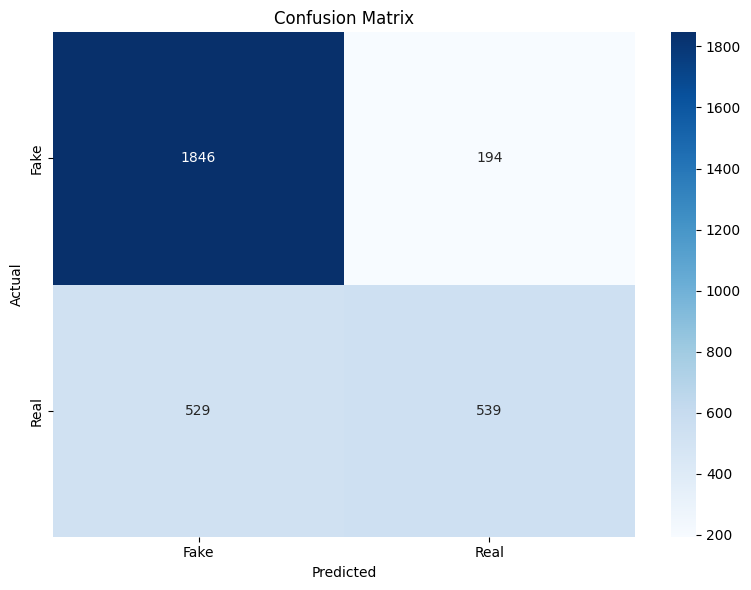

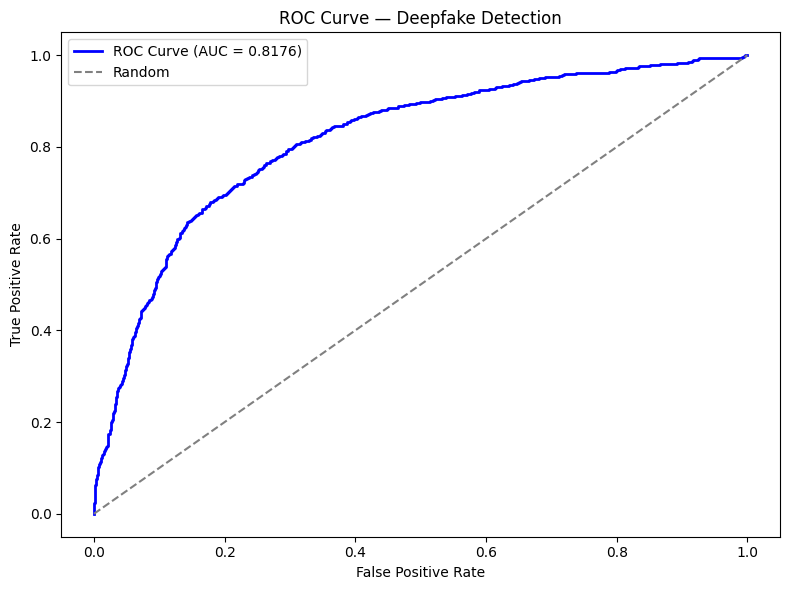


--- Classification Report ---
              precision    recall  f1-score   support

        Fake       0.78      0.90      0.84      2040
        Real       0.74      0.50      0.60      1068

    accuracy                           0.77      3108
   macro avg       0.76      0.70      0.72      3108
weighted avg       0.76      0.77      0.75      3108



In [22]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import seaborn as sns

THRESHOLD = 0.6
y_pred_final = (y_pred_prob > THRESHOLD).astype(int).flatten()

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Deepfake Detection')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve.png', dpi=150)
plt.show()

# --- Classification Report ---
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred_final,
                            target_names=['Fake', 'Real']))